In [50]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import IPython.display as ipd
import yaml
from pathlib import Path

In [51]:
with open("../configs/config.yaml", "r") as f:
    config = yaml.safe_load(f)

In [52]:
audio_path = Path(config["directories"]["audio_data_path"])
metadata = Path(config["directories"]["metadata"])

In [53]:
df = pd.read_csv(metadata)

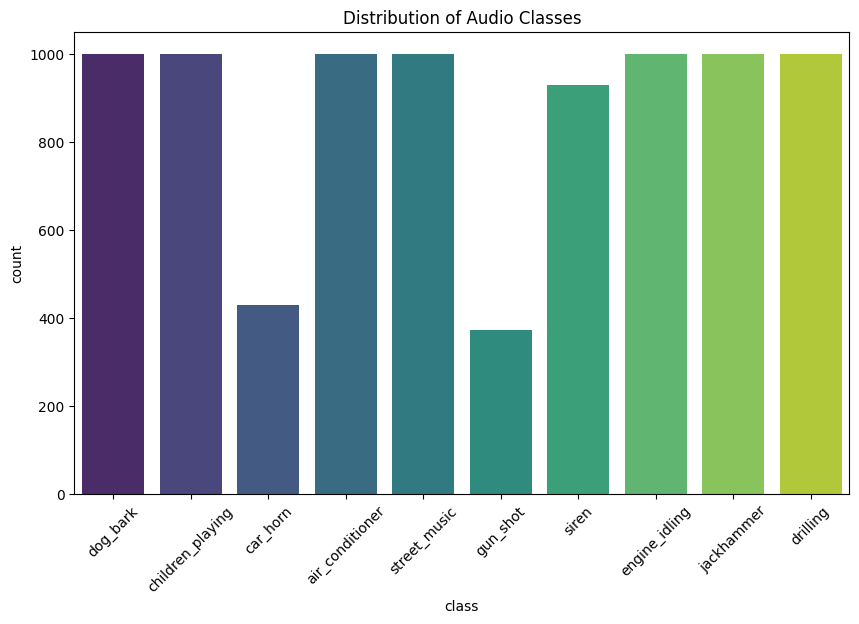

In [54]:
plt.figure(figsize=(10, 6))
sns.countplot(x='class', data=df, hue='class', palette='viridis', legend=False)
plt.title('Distribution of Audio Classes')
plt.xticks(rotation=45)
plt.show()

In [55]:
df['duration'] = df['end'] - df['start']
print(df['duration'].describe())

count    8732.000000
mean        3.607904
std         0.973570
min         0.054517
25%         4.000000
50%         4.000000
75%         4.000000
max         4.000000
Name: duration, dtype: float64


In [56]:
def plot_audio_analysis(file_path, class_label):
    # Load audio file (resampled to 22.05kHz by default)
    data, sr = librosa.load(file_path)
    
    # Create the figure
    plt.figure(figsize=(12, 10))
    
    # Add a main title for the whole plot
    plt.suptitle(f"Class: {class_label}", fontsize=16, fontweight='bold')
    
    # 1. Plot Waveform
    plt.subplot(2, 1, 1)
    librosa.display.waveshow(data, sr=sr)
    plt.title(f'Waveform - {class_label}')
    plt.ylabel('Amplitude')
    
    # 2. Plot Mel-Spectrogram
    plt.subplot(2, 1, 2)
    S = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(img, format='%+2.0f dB')
    plt.title(f'Mel-Spectrogram - {class_label}')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
    plt.show()

In [57]:
row = df.sample(1).iloc[0]
path = f"{audio_path}/fold{row['fold']}/{row['slice_file_name']}"

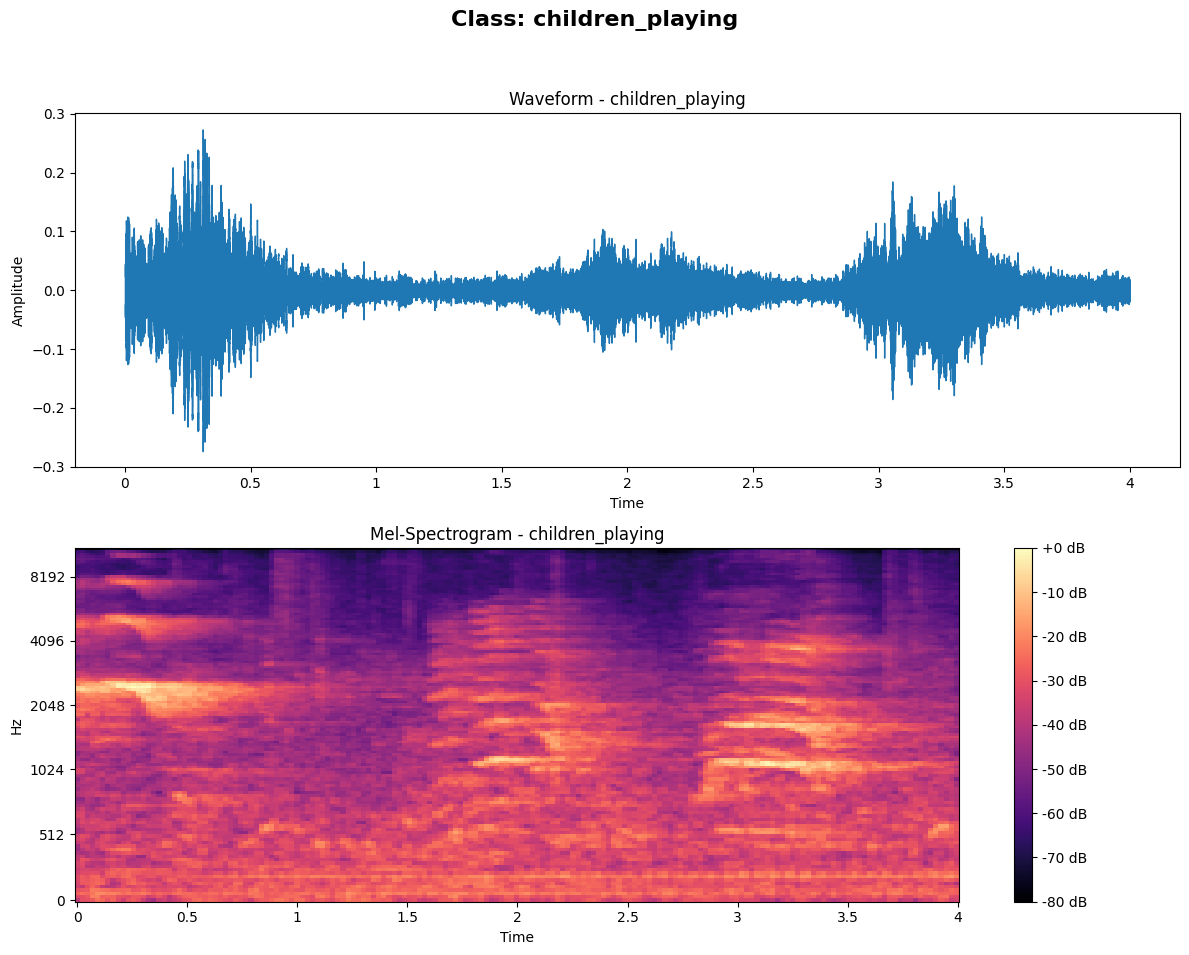

In [58]:
plot_audio_analysis(path, row['class'])